# 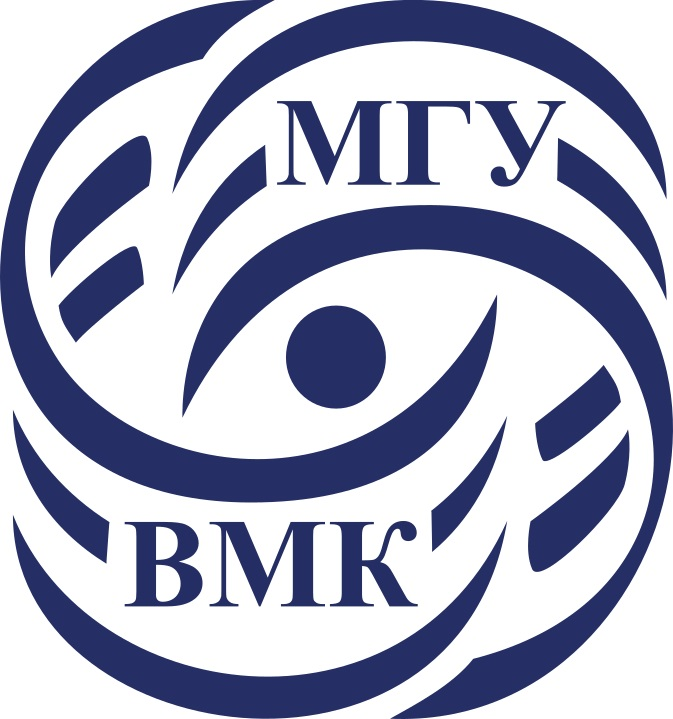

# Машинное обучение. ВМК МГУ

# Практическое задание 7: SVM
## Уровень: <font color='SkyBlue'>**Базовый (Base)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

Цель данного задания:

* Изучите работу модели SVM
* Поймете, как с её помощью можно строить нелинейные разделяющие поверхности
* Потренируетесь в подборе оптимальных параметров на обучающей выборке для достижения наилучшего качества на закрытой выборке (ML-решение)

-------
<font color="white" style="opacity:0.2024"></font>
<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: до 10 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)


In [ ]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
! pip install -r /content/requirements_2024_25_for_colab_small.txt

Downloading...
From: https://drive.google.com/uc?id=10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
To: C:\Users\mozhu\PycharmProjects\ML_2024\Task7\Base\requirements_2024_25_for_colab_small.txt

  0%|          | 0.00/375 [00:00<?, ?B/s]
100%|##########| 375/375 [00:00<?, ?B/s] 
ERROR: Could not open requirements file: [Errno 2] No such file or directory: '/content/requirements_2024_25_for_colab_small.txt'


Проверим версию библиотеки:

In [1]:
import catboost


assert (catboost.__version__ == '1.2.7')

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2023"></font>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from copy import copy

Если Вы дальтоник, то можете воспользоваться готовой colormap из matplotlib (или найти свою):
```
plt.style.use('tableau-colorblind10')
```

Приведем вспомогательный код

In [ ]:
from matplotlib.colors import ListedColormap

from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, train_test_split
from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score
from sklearn.datasets import make_blobs, make_circles, make_moons

In [ ]:
def make_moons_cls(size=1000, d=2):
    X, y = make_moons(n_samples=size, noise=0.15)
    if d > 2:
        X = np.concatenate((X, np.random.normal(size=(size, d - 2))), axis=1)
    return X, y


def make_circles_cls():
    X, y = make_circles()


def generate_data_with_imb_classes(size1=100, size2=10):
    X = np.r_[(
        np.random.normal(loc=1.0, size=(size1, 2)),
        np.random.normal(loc=0.5, size=(size2, 2))
    )]

    y = np.ones(len(X))
    y[-size2:] = 0
    return X, y

In [ ]:
def plot_separating_surface(X, y, cls, view_support=False, title=''):
    x_min = min(X[:, 0]) - 0.1
    x_max = max(X[:, 0]) + 0.1
    y_min = min(X[:, 1]) - 0.1
    y_max = max(X[:, 1]) + 0.1
    h = 0.005
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = cls.predict(np.c_[xx.ravel(), yy.ravel()])

    plt.figure(figsize=(10, 10))
    if title:
        plt.title(title)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=40, cmap=cm_bright)
    if view_support:
        plt.scatter(X[cls.support_, 0], X[cls.support_, 1],
                    c=y[cls.support_], edgecolors='k', s=150, cmap=cm_bright)
    Z = Z.reshape(xx.shape)
    plt.xticks(())
    plt.yticks(())
    plt.contourf(xx, yy, Z, cmap=cm, alpha=.3)
    plt.show()

# Загрузка данных

In [ ]:
import gdown

gdown.download_folder('https://drive.google.com/drive/folders/1bp39_Jj0edo1lzxZ3DIoChsOVy5DVi1R?usp=sharing')

Retrieving folder contents


Retrieving folder 1tv605hGxdQtd4zC787DbcRF0312gDeK_ imbalanced
Processing file 14zd2xHDChSHtMWQ_TUzM8td7s8gzCO2u X_imb_test.npz.npy
Processing file 1Qed066d3gUsUOZiUZu6aCrIH9f0yWKSc X_imb.npz.npy
Processing file 1uD87Xbh4MMBBn5fsScrknI54SINIqory y_imb_test.npz.npy
Processing file 1RR2VU_6WJMLo88k8C1VzBwb2Ibnz1yJf y_imb.npz.npy
Retrieving folder 1uoI6vZWwIII1jd2k5TtsZTJ3JOkK0G6O public
Processing file 1Win7ZtHLHEbDtX6x6O7vBJHwJviQxbp5 cX_test.npy
Processing file 1MowPnLFAMEjjcAjDA4skE4OUFdmaiSY6 cX_train.npy
Processing file 1VYA4N5wCQhwteQSZkDogFTha2xRv0FgW cy_train.npy


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=14zd2xHDChSHtMWQ_TUzM8td7s8gzCO2u
To: C:\Users\mozhu\PycharmProjects\ML_2024\Task7\Base\05-SVM\imbalanced\X_imb_test.npz.npy
100%|██████████| 2.05k/2.05k [00:00<00:00, 3.82MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Qed066d3gUsUOZiUZu6aCrIH9f0yWKSc
To: C:\Users\mozhu\PycharmProjects\ML_2024\Task7\Base\05-SVM\imbalanced\X_imb.npz.npy
100%|██████████| 2.05k/2.05k [00:00<?, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1uD87Xbh4MMBBn5fsScrknI54SINIqory
To: C:\Users\mozhu\PycharmProjects\ML_2024\Task7\Base\05-SVM\imbalanced\y_imb_test.npz.npy
100%|██████████| 1.09k/1.09k [00:00<00:00, 2.04MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RR2VU_6WJMLo88k8C1VzBwb2Ibnz1yJf
To: C:\Users\mozhu\PycharmProjects\ML_2024\Task7\Base\05-SVM\imbalanced\y_imb.npz.npy
100%|██████████| 1.09k/1.09k [00:00<00:00, 1.0

['C:\\Users\\mozhu\\PycharmProjects\\ML_2024\\Task7\\Base\\05-SVM\\imbalanced\\X_imb_test.npz.npy',
 'C:\\Users\\mozhu\\PycharmProjects\\ML_2024\\Task7\\Base\\05-SVM\\imbalanced\\X_imb.npz.npy',
 'C:\\Users\\mozhu\\PycharmProjects\\ML_2024\\Task7\\Base\\05-SVM\\imbalanced\\y_imb_test.npz.npy',
 'C:\\Users\\mozhu\\PycharmProjects\\ML_2024\\Task7\\Base\\05-SVM\\imbalanced\\y_imb.npz.npy',
 'C:\\Users\\mozhu\\PycharmProjects\\ML_2024\\Task7\\Base\\05-SVM\\public\\cX_test.npy',
 'C:\\Users\\mozhu\\PycharmProjects\\ML_2024\\Task7\\Base\\05-SVM\\public\\cX_train.npy',
 'C:\\Users\\mozhu\\PycharmProjects\\ML_2024\\Task7\\Base\\05-SVM\\public\\cy_train.npy']

# SVM и разделяющая поверхность

На лекции вы изучили, что линейная, с виду, модель SVM, при помощи некоторых "фокусов", называемых ядрами, умеет строить нелинейные поверхности. В данном ноутбуке посмотрим, как это все работает на практике, и какие гиперпараметры настройки у этого метода есть.

<font color='MediumTurquoise'>**Историческая справка:**</font> Метод опорных векторов (SVM) стал популярным в 90-х годах, особенно с 1995 года, благодаря своей эффективности в задачах классификации и способности обрабатывать высокоразмерные данные. Он также привлек внимание благодаря использованию ядровых функций, что позволяло решать нелинейные задачи. Однако с появлением более сложных методов, таких как глубокое обучение, и увеличением объема данных, SVM стал менее популярным, поскольку более современные алгоритмы демонстрировали лучшие результаты на больших наборах данных и обеспечивали более простую настройку.

## <font color='DarkOrange'>**Задание 1 [1 балл]**</font>


В ячейке ниже генерируется выборка, состоящая из объектов двух классов. Каждый объект представлен двумя координатами, так что объекты этой выборки можно отобразить на плоскости, используя функцию scatter из библиотеки matplotlib.


    
В этом задании вам надо будет обучить линейную разделяющую поверхность с помощью $\mbox{sklearn.svm.SVC(kernel='linear')}$, а также нелинейную c rbf-ядром с помощью $\mbox{sklearn.svm.SVC(kernel='rbf')}$. Остальные параметры методов можете оставить дефолтными. Делить выборку на обучение и валидацию сейчас не требуется, так как нас будет пока интересовать только форма разделяющей кривой.

In [ ]:
X, y = make_moons_cls()
linear_svc = SVC(kernel='linear')
nonlinear_svc = SVC(kernel='rbf')

Визуализируем выборку

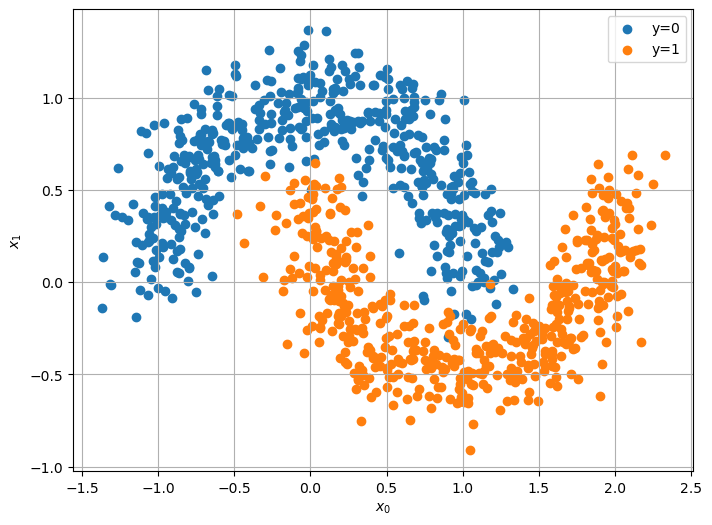

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='y=0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='y=1')
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.legend()
plt.grid()

Обучите модели и визуализируйте разделяющую поверхность для обеих моделей с помощью функции plot_separating_surface(). Посчитайте точность (accuracy) на обучающей выборке для каждой из моделей.

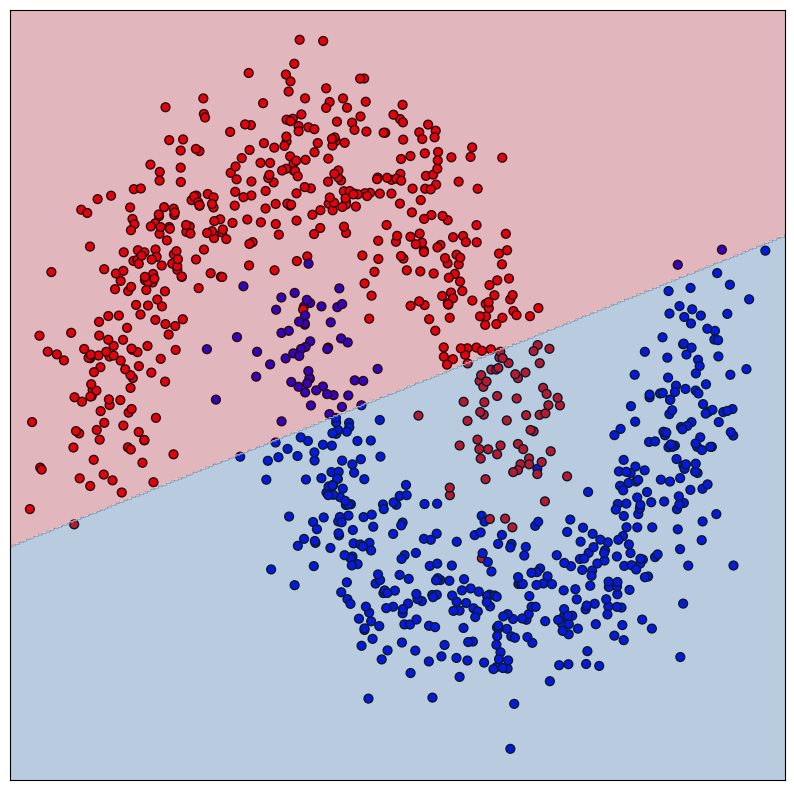

Train Accuracy (linear): 0.878


In [ ]:
linear_svc.fit(X, y)
plot_separating_surface(X, y, linear_svc)
print(f'Train Accuracy (linear): {accuracy_score(y, linear_svc.predict(X)):.3f}')

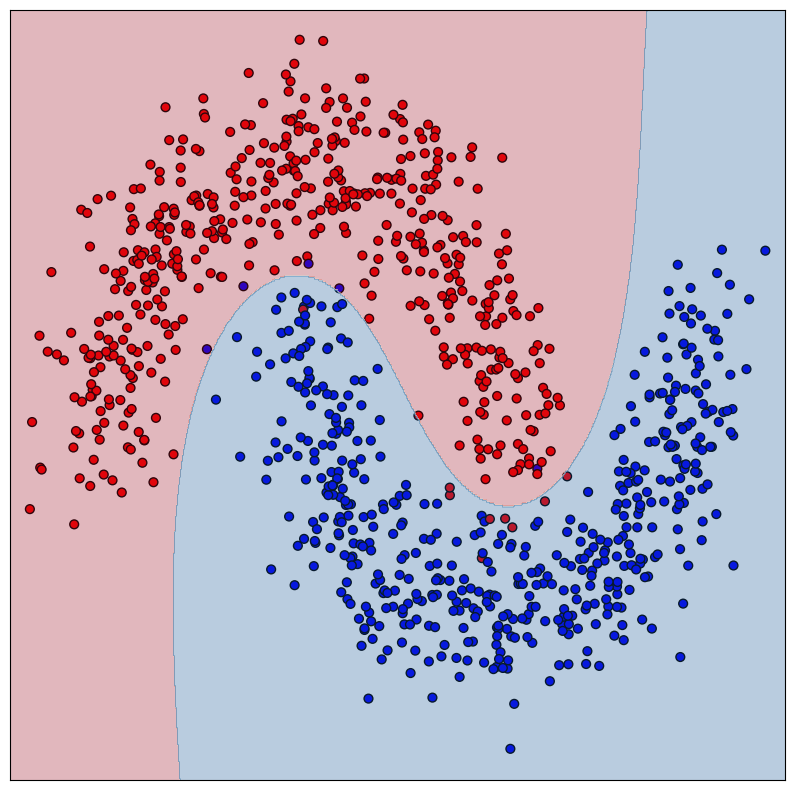

Train Accuracy (non linear): 0.986


In [ ]:
nonlinear_svc.fit(X, y)
plot_separating_surface(X, y, nonlinear_svc)
print(f'Train Accuracy (non linear): {accuracy_score(y, nonlinear_svc.predict(X)):.3f}')

**Сделайте вывод**
о получившихся результатах. Какая из моделей лучше подходит для данной выборки и почему?

<font color='MediumOrchid'>**Ваши выводы тут:**</font> Для классификации данной выборки лучше подходит модель с $rbf-ядром$, так как приведённые данные невозможно достаточно точно разделить линейной функцией. Это отражено в значительно более высоком $accuracy$ у второй модели.

## 2. Опорные объекты

Продолжаем работать с выборкой и моделями из первой части. Для линейной и rbf-моделей рассмотрим
    опорные объекты, полученные после обучения. Визуализировать их можно, используя функуцию plot_separating_surface с параметром vis_support=True. Достанем опорные объекты из обученной модели с помощью поля model.support_.

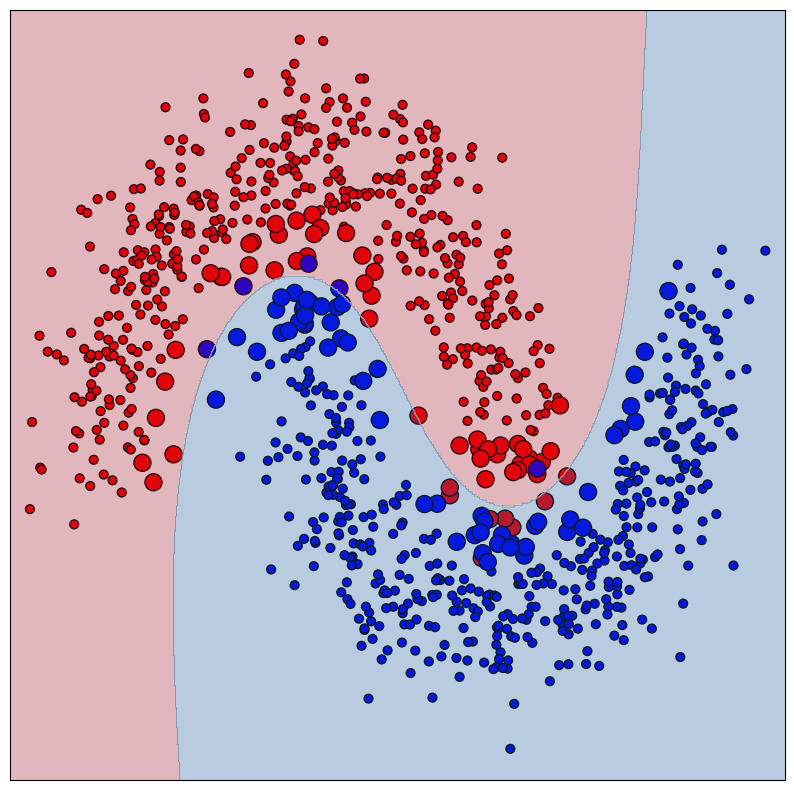

In [ ]:
plot_separating_surface(X, y, nonlinear_svc, view_support=True)

Обучим новые две модели $\mbox{SVC(kernel='rbf')}$, используя только опорные объекты построенные с помощью соответственно линейной (linear_svc) и нелинейной (nonlinear_svc) моделей из первой части.

In [ ]:
# Учим модели только на опорных объектах
svc_on_linear_support = SVC(kernel='rbf').fit(X[linear_svc.support_, :], y[linear_svc.support_])
svc_on_rbf_support = SVC(kernel='rbf').fit(X[nonlinear_svc.support_, :], y[nonlinear_svc.support_])

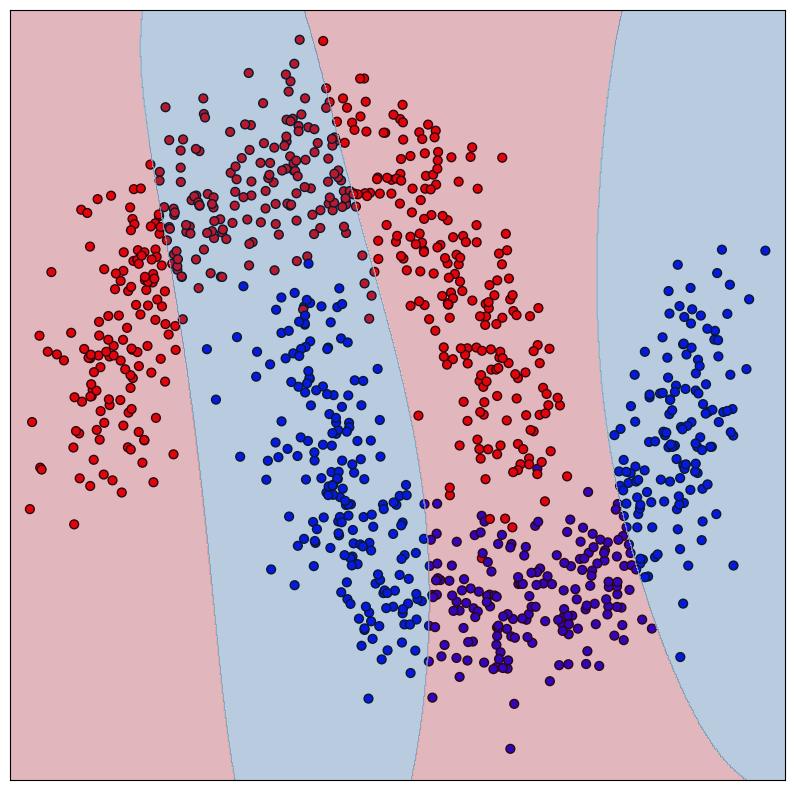

In [ ]:
plot_separating_surface(X, y, svc_on_linear_support)

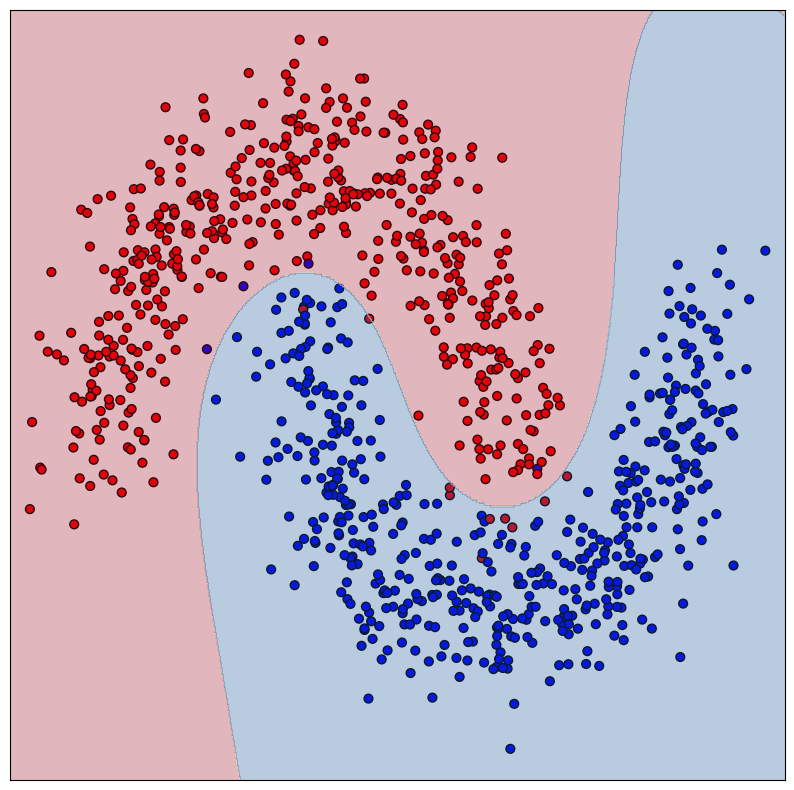

In [ ]:
plot_separating_surface(X, y, svc_on_rbf_support)

### <font color='DarkOrange'>**Задание 2 [1 балл]**</font>

Сравните полученные разделяющие поверхности с нелинейной моделью (nonlinear_svc) из задания 1. Какая из поверхностей больше похожа на нелинейнную модель из первой части и почему, опишите в выводе.


<font color='MediumOrchid'>**Ваши выводы тут:**</font> Больше всего на нелинейную модель из первой части похожа поверхность, обученная на опорных векторах нелинейной модели (т.е. модель 2).

Почему это происходит:
1. Обучаясь на опорных векторах **нелинейной** модели, в качестве новых опорных векторов будет выбрано некоторое их подмножество, а значит и гиперплоскость будет отличаться незначительно (см. первую визуализацию ниже)
2. Если же обучение будет происходить на о.в. линейной **модели**, то в силу того, что сами эти вектора были вычислены в соответствии с общими принципами вычисления опорных векторов:
    * Опорные векторы выбираются так, чтобы расстояние от них до разделяющей гипперплоскости соответствовало маргинальному зазору
    * Опорные векторы выбираются так, чтобы модель смогла минизировать функцию потери. Так как в случае линейной модели мы не можем корректно разделить данные (ибо они линейно неразделимы), то опорные векторы будут выбраны так, чтобы ошибка была как можно меньше, однако далеко не идеальной.
    * Если мы обучим нелинейную модель на этих о.п., то полученная нелинейная поверхность корреткно разделит эти "некорректные о.п.", однако это будет слабо отражать реальное распеределение классов
    * Как выглядят о.п. для линейной модели вы можете увидеть на второй визуализации ниже

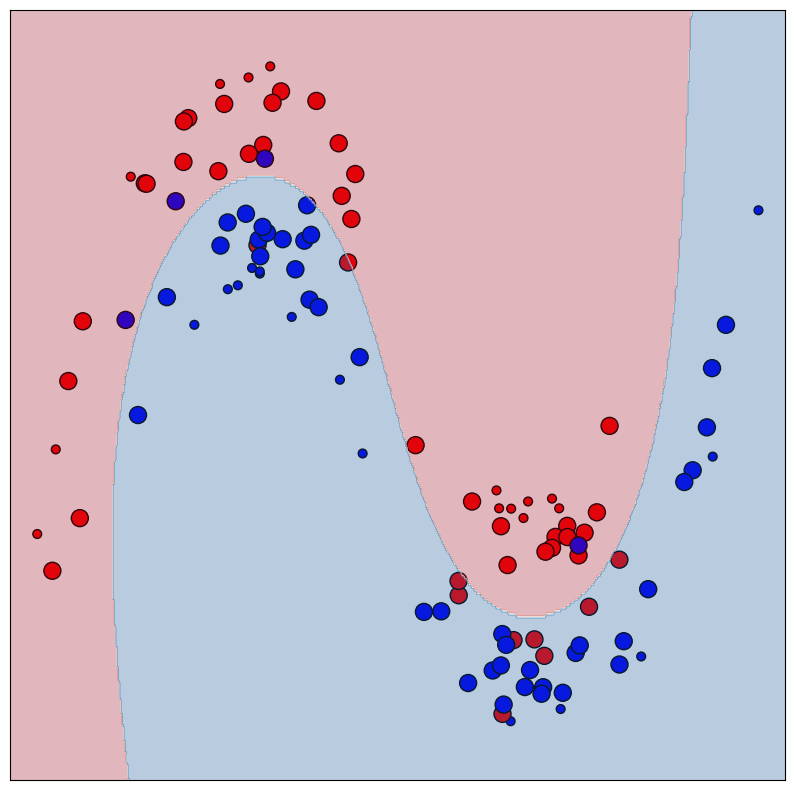

In [ ]:
plot_separating_surface(X[nonlinear_svc.support_, :], y[nonlinear_svc.support_], svc_on_rbf_support, view_support=True)

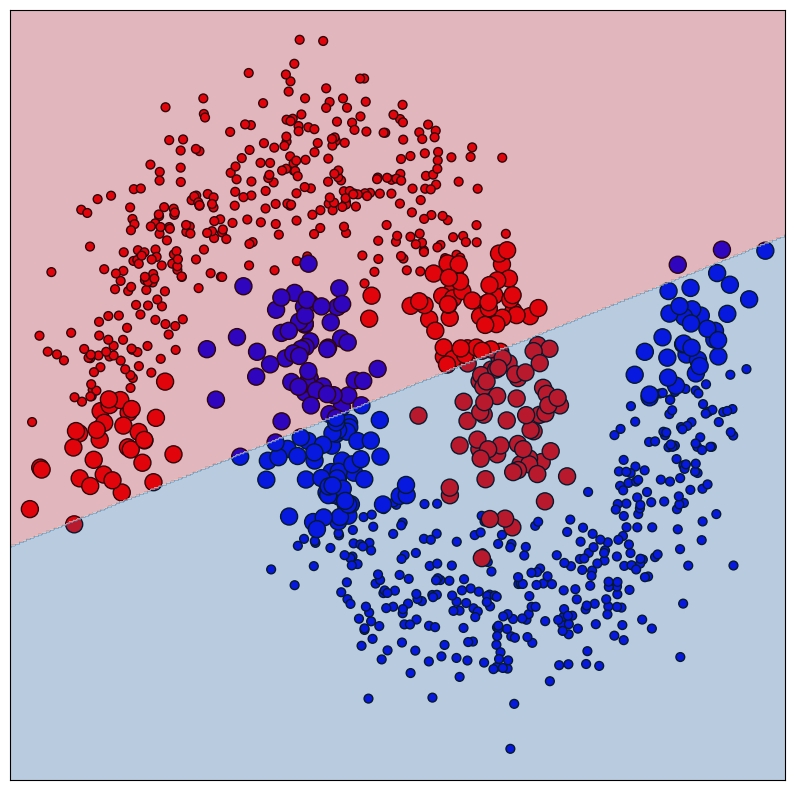

In [ ]:
plot_separating_surface(X, y, linear_svc, view_support=True)

---

Теперь обучим модель $\mbox{SVC(kernel='rbf')}$, используя все объекты кроме тех, что являлись опорными для нелинейной модели из первой части (nonlinear_svc) и сравним эту модель вместе с svc_on_rbf_support с нелинейной моделью из задания 1(nonlinear_svc). Визуализируйте разделяющие поверхности обеих моделей.

In [ ]:
non_support_vectors = [i for i in range(len(X)) if i not in nonlinear_svc.support_]
svc_all_without_rbf_support = SVC(kernel='rbf').fit(X[non_support_vectors, :], y[non_support_vectors])

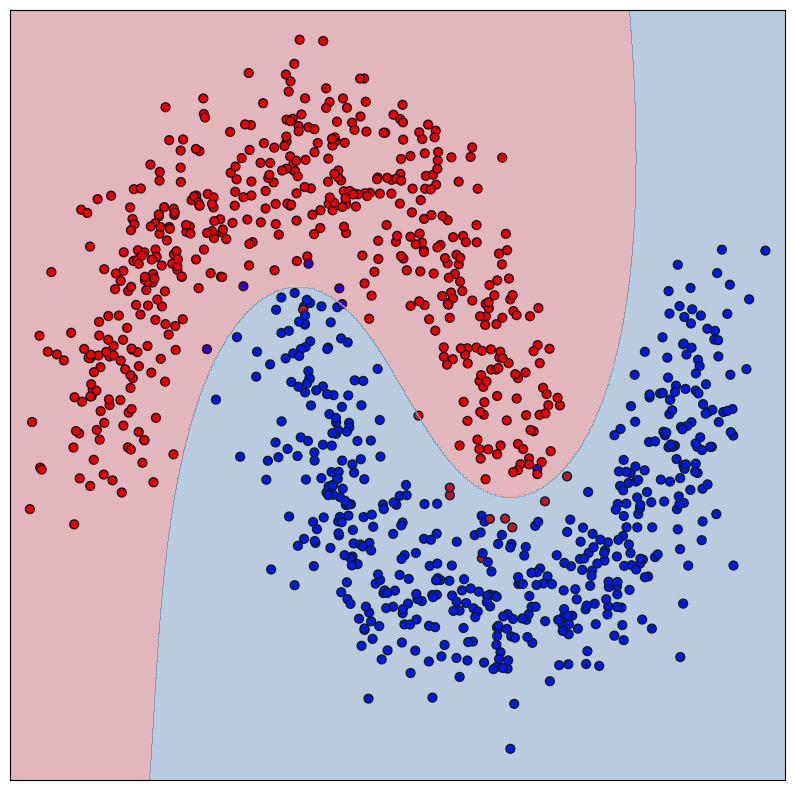

Train Accuracy: 0.985


In [ ]:
plot_separating_surface(X, y, svc_all_without_rbf_support)
print(f'Train Accuracy: {accuracy_score(y, svc_all_without_rbf_support.predict(X)):.3f}')

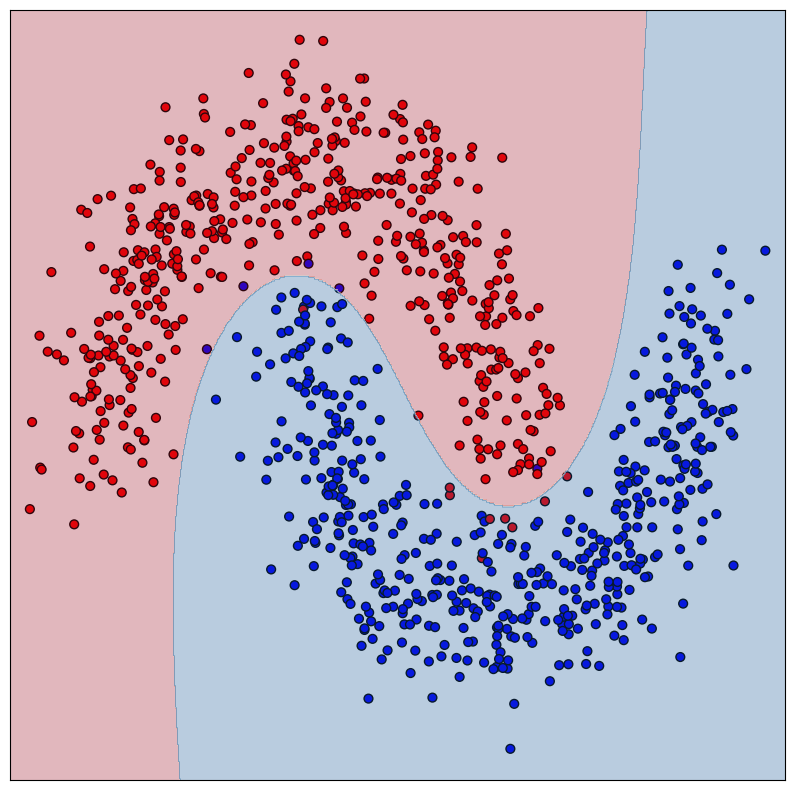

Train Accuracy: 0.986


In [ ]:
plot_separating_surface(X, y, nonlinear_svc)
print(f'Train Accuracy: {accuracy_score(y, nonlinear_svc.predict(X)):.3f}')


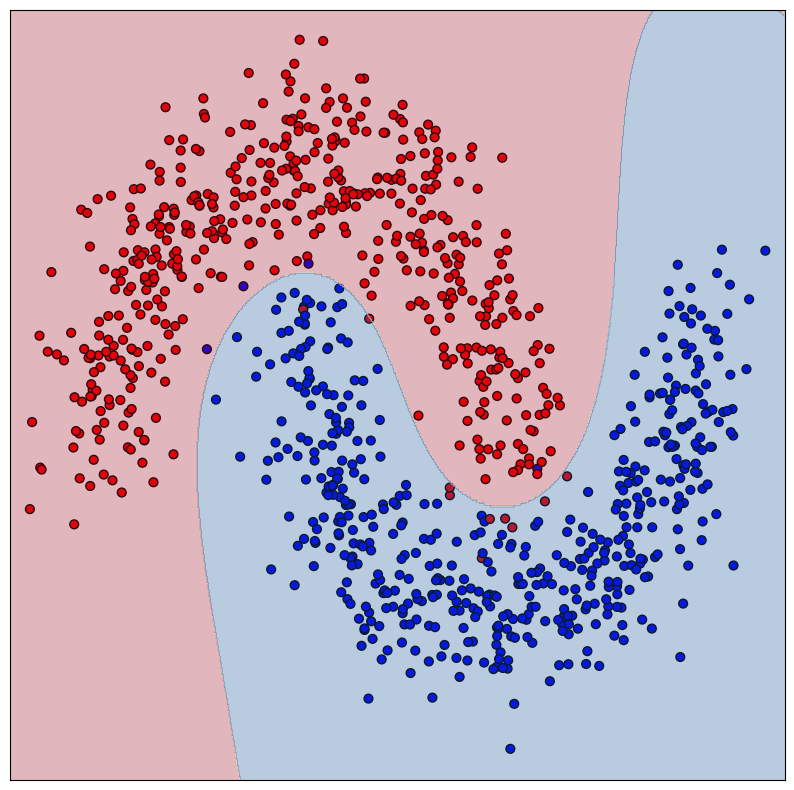

Train Accuracy: 0.986


In [ ]:
plot_separating_surface(X, y, svc_on_rbf_support)
print(f'Train Accuracy: {accuracy_score(y, svc_on_rbf_support.predict(X)):.3f}')


### <font color='DarkOrange'>**Задание 3 [1.5 баллa]**</font>

**Сделайте вывод:** Сильно ли полученные поверхности отличаются от той, что была получена в первом задании? Что произошло с пограничными объектами? Объясните полученные результаты.

<font color='MediumOrchid'>**Ваши выводы тут:**</font> Приведённые графики выглядят весьма похоже, однако, если обратить внимание на краевые точки, то можно заметить следующие отличия:
1. Модель, обученная на полной выборке, а также модель, обученная чисто на опорных векторах лучше справляются с классификацией граничных точек. Подобный результат демонстрирует, что опорные вектора являются важными для качественной классификации
2. Модель, обученная на выборке без опорных векторов, выдаёт большее количество ошибок в граничных случаях. Это ещё раз показывает необходимость наличия опорных векторов для корректной классификации, ведь они необходимы для построения границы необходимой формы


# 4. Обучите лучшую SVM модель (ML-решение)

Возможность строить нелинейные поверхности может сильно улучшить качество, но и несет риск переобучения.
    В этом задании предстоит обучить лучшую svm модель и получить хорошее качество на тесте в системе тестирования. Для контроля переобучения рекомендуется пользоваться кросс-валидацией. Для улучшения качества рекомендуется подбирать

1. параметр регуляризации C;
2. тип разделяющей кривой linear/rbf/poly;
3. степень в случае разделяющей кривой poly.

Также не забывайте, что при решении задач машинного обучения полезно смотреть в данные :)

Все csv-таблицы с данными вы можете взять из публичного теста, который также есть в проверяющей системе. Для этого распакуйте архив с публичными тестами и положите файлы в рабочей директории (рядом с ноутбуком)

In [ ]:
X_train = np.load('05-SVM/public/cX_train.npy')
y_train = np.load('05-SVM/public/cy_train.npy')
X_test = np.load('05-SVM/public/cX_test.npy')

In [ ]:
X_train.shape, y_train.shape, X_test.shape

((800, 5), (800,), (200, 5))

In [ ]:
X = X_train
y = y_train.ravel()

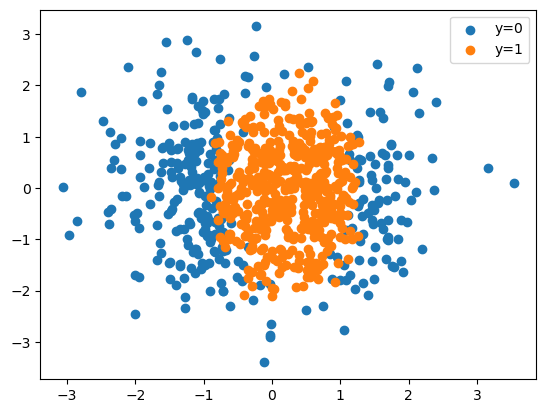

In [ ]:
plt.scatter(X[y == 0, 4], X[y == 0, 3], label='y=0')
plt.scatter(X[y == 1, 4], X[y == 1, 3], label='y=1')
plt.legend()

**Отправьте код обучения модели с оптимальными параметрами в проверяющую систему, воспользовавшись приложенным шаблоном svm_solution.py. Кросс-валидацию параметров в посылаемом решении делать <font color='red'>не нужно</font> -- достаточно подобрать, например, их тут, а в решении уже обучать модель с оптимальными параметрами.**

# Сравнение с логистической регрессией

#### <font color='DarkOrange'>**Задание 4 [1.5 баллa]**</font>

В предыдущей части Вы обучили хорошую SVM модель, подбирая гиперпараметры модели. Давайте теперь попробуем обучить логистическую регрессию на этой же выборке, и по кросс-валидации оценить влияние гиперпараметров на линейную модель.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
parameters = {
    'C': np.logspace(-4, 4, 10),
    'penalty': [None, 'l2'],
    'solver': ['newton-cg', 'sag', 'saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': np.arange(1000, 100000, 10000),
}

In [ ]:
pipe = Pipeline(steps=[('scaler', StandardScaler()), ('classifier', LogisticRegression(tol=0.00000001))])

In [ ]:
grid_search = GridSearchCV( LogisticRegression(tol=0.00000001), parameters, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

D:\Programs\Anaconda\envs\conda_env_24_25\lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
D:\Programs\Anaconda\envs\conda_env_24_25\lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


GridSearchCV(cv=5, estimator=LogisticRegression(tol=1e-08), n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                         'class_weight': [None, 'balanced'],
                         'max_iter': array([ 1000, 11000, 21000, 31000, 41000, 51000, 61000, 71000, 81000,
       91000]),
                         'penalty': [None, 'l2'],
                         'solver': ['newton-cg', 'sag', 'saga']},
             scoring='accuracy')

In [ ]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Лучшие параметры: {'C': 0.0001, 'class_weight': None, 'max_iter': 1000, 'penalty': None, 'solver': 'newton-cg'}
Лучшая точность: 0.7765625


In [ ]:
pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,param_max_iter,param_penalty,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003855,0.000894,0.001293,0.000351,0.000100,None,1000,None,newton-cg,"{'C': 0.0001, 'class_weight': None, 'max_iter'...",0.773438,0.773438,0.757812,0.757812,0.820312,0.776563,0.022964,1
654,0.004004,0.000004,0.001305,0.000402,2.782559,None,91000,None,newton-cg,"{'C': 2.782559402207126, 'class_weight': None,...",0.773438,0.773438,0.757812,0.757812,0.820312,0.776563,0.022964,1
656,0.005301,0.002889,0.001203,0.000399,2.782559,None,91000,None,saga,"{'C': 2.782559402207126, 'class_weight': None,...",0.773438,0.773438,0.757812,0.757812,0.820312,0.776563,0.022964,1
657,0.004203,0.001467,0.000903,0.000494,2.782559,None,91000,l2,newton-cg,"{'C': 2.782559402207126, 'class_weight': None,...",0.773438,0.773438,0.757812,0.757812,0.820312,0.776563,0.022964,1
658,0.005998,0.001097,0.001201,0.000400,2.782559,None,91000,l2,sag,"{'C': 2.782559402207126, 'class_weight': None,...",0.773438,0.773438,0.757812,0.757812,0.820312,0.776563,0.022964,1


Сделайте выводы о влиянии выбора гиперпараметров на качество обучения линейной и SVC моделей. Также опишите, какие преобразования выборки/подбор каких гиперпараметров помогли добиться высокого качества на кросс-валидации в данной задаче.

<font color='MediumOrchid'>**Ваши выводы тут:**</font>При обучении линейной модели подбор различных гиперпаметров оказал незначительное влияние на результат. В то время как при обучении $SVM$-модели, перебор гиперпараметров был одним из ключевых моментов. Были перебраны такие гиперпараметры как:
1. **Тип ядра**: `rbf`, `poly` и `sigmoid`
2. **С**: от `0.01` до `20`
3. **gamma**: от `0.001` до `10`
4. **class_weight**: `None` и `balanced`

### <font color='MediumSeaGreen'>**Задание 5 [1 балл][Bonus]**</font>

Найдите мем про SVM лучше чем этот:

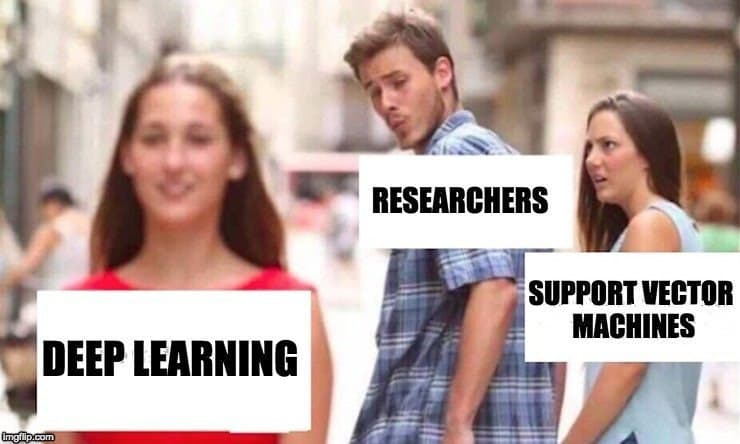

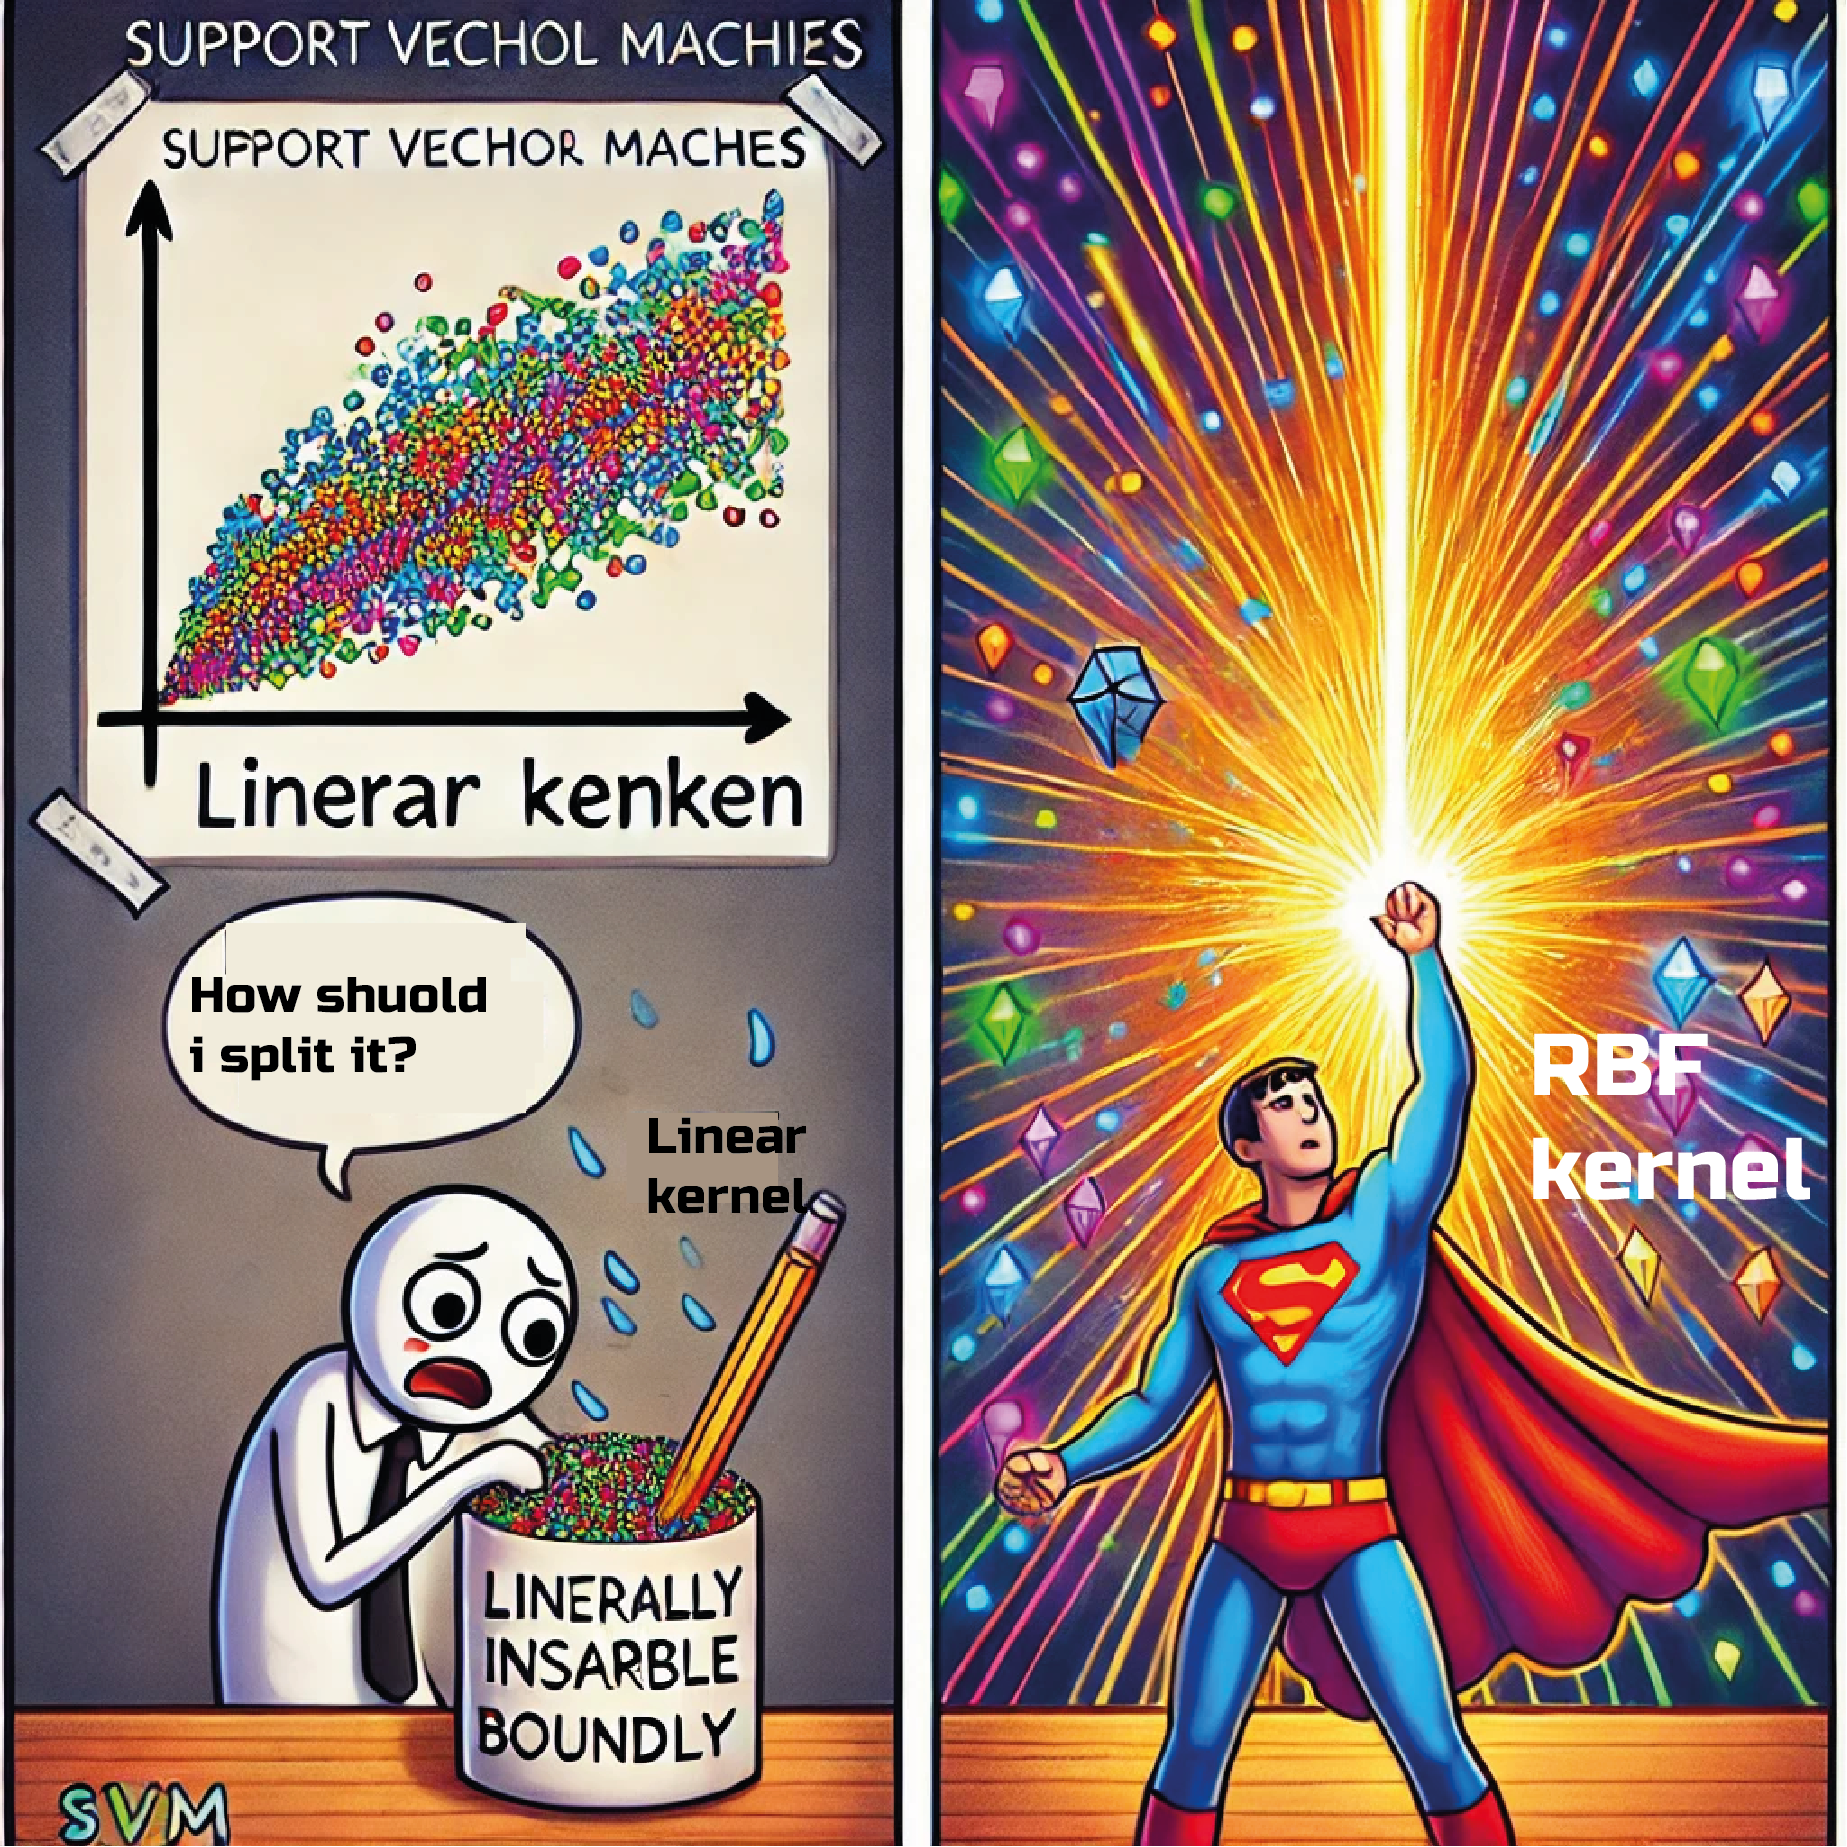